In [ ]:
# ==========================================
# 01_LIANA_CCC.ipynb
# Purpose:
# Run LIANA+ cell-cell communication analysis
# on the Xenopus -> Human mapped scRNA-seq dataset.
#
# Notebook location:
# KU_Thesis_2026/LIANA/notebooks/
#
# Input data:
# ../../Xenopus_to_Human/data/adata_human_mapped.h5ad
#
# Outputs:
# ../results/liana_rank_aggregate_results.csv
# ../results/liana_top_interactions.csv
# ==========================================

In [1]:
# Step 1: Import required packages

import os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import liana as li
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("scanpy version:", sc.__version__)
print("anndata version:", ad.__version__)
print("liana version:", li.__version__)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


scanpy version: 1.10.3
anndata version: 0.10.8
liana version: 1.5.0


In [2]:
# Step 2: Define file paths

# Input file
adata_path = "../../Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad"

# Output directory
results_dir = "../results"
figures_dir = "../figures"

# Create output folders if they do not already exist
os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

print("Input AnnData path:", adata_path)
print("Results directory:", results_dir)
print("Figures directory:", figures_dir)

Input AnnData path: ../../Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad
Results directory: ../results
Figures directory: ../figures


In [3]:
# Step 3: Load human-mapped AnnData object

adata = sc.read_h5ad(adata_path)

print(adata)
print("Shape:", adata.shape)
print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

AnnData object with n_obs × n_vars = 29800 × 11119
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample'
    var: 'human_symbol'
Shape: (29800, 11119)
Number of cells: 29800
Number of genes: 11119


In [4]:
# Step 4: Inspect metadata and gene names

print("obs columns:")
print(adata.obs.columns.tolist())

print("\nFirst 10 genes:")
print(adata.var_names[:10].tolist())

print("\nDuplicated gene names:", adata.var_names.duplicated().sum())

obs columns:
['barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample']

First 10 genes:
['A1CF', 'A2M', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADACL4', 'AADAT', 'AAGAB', 'AAMP']

Duplicated gene names: 0


In [5]:
# Step 5: Check cell type annotations

# Change this if your annotation column has another name
celltype_col = "CellType"

print("Missing cell type labels:", adata.obs[celltype_col].isna().sum())
print("\nCell type counts:")
print(adata.obs[celltype_col].value_counts())

Missing cell type labels: 0

Cell type counts:
CellType
Early epithelial progenitor    11420
Basal                           7601
Pluripotent                     5541
Multiciliated                   2322
Goblet                          1955
Ionocyte                         961
Name: count, dtype: int64


In [6]:
# Step 6: Filter genes expressed in too few cells

print("Shape before filtering:", adata.shape)

sc.pp.filter_genes(adata, min_cells=10)

print("Shape after filtering:", adata.shape)

Shape before filtering: (29800, 11119)
Shape after filtering: (29800, 9251)


In [7]:
# Step 7: Check expression matrix

print("Matrix type:", type(adata.X))
print("Example values from expression matrix:")
print(adata.X[:5, :5])

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Example values from expression matrix:



In [8]:
# Step 8: Save a filtered copy for LIANA

filtered_adata_path = "../results/adata_human_mapped_filtered_for_liana.h5ad"
adata.write(filtered_adata_path)

print("Saved filtered AnnData to:", filtered_adata_path)

Saved filtered AnnData to: ../results/adata_human_mapped_filtered_for_liana.h5ad


In [9]:
# Step 9: Run LIANA cell-cell communication inference

li.mt.rank_aggregate(
    adata,
    groupby=celltype_col,
    resource_name="consensus",
    expr_prop=0.1,
    use_raw=False,
    verbose=True
)

print("LIANA run completed.")

Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.68 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 29800 samples and 446 features
Assuming that counts were `natural` log-normalized!


/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:04<00:00, 248.63it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
LIANA run completed.


In [10]:
# Step 10: Extract LIANA results table

liana_res = adata.uns["liana_res"]

print(type(liana_res))
print("LIANA result shape:", liana_res.shape)
print("\nColumns:")
print(liana_res.columns.tolist())

liana_res.head()

<class 'pandas.core.frame.DataFrame'>
LIANA result shape: (76, 13)

Columns:
['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank']


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
6,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.818034,12.608398,0.220204,0.980048,0.016043,0.001545
13,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246
9,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379132,-8.516525,0.108186,0.971775,0.579032,0.053142
23,Early epithelial progenitor,Basal,MDK,NCL,2.412407,0.000,0.952426,0.253559,8.330219,0.035448,0.951710,0.491650,0.071662
16,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662


In [12]:
# Step 11: Save full LIANA results

full_results_path = os.path.join(results_dir, "liana_rank_aggregate_results.csv")
liana_res.to_csv(full_results_path, index=False)

print("Saved full LIANA results to:", full_results_path)

Saved full LIANA results to: ../results/liana_rank_aggregate_results.csv


In [11]:
# Step 12: Create ligand-receptor pair label

liana_res["lr_pair"] = (
    liana_res["ligand_complex"].astype(str) +
    " -> " +
    liana_res["receptor_complex"].astype(str)
)

liana_res[["source", "target", "lr_pair"]].head()

,source,target,lr_pair
6,Basal,Basal,MDK -> NCL
13,Basal,Goblet,MDK -> NCL
9,Basal,Early epithelial progenitor,MDK -> NCL
23,Early epithelial progenitor,Basal,MDK -> NCL
16,Basal,Ionocyte,MDK -> NCL


In [12]:
# Step 13: Rank top interactions

# Lower magnitude_rank usually means stronger / better ranked interaction
top_interactions = liana_res.sort_values("magnitude_rank", ascending=True).copy()

top_interactions.head(20)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair
6,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.818034,12.608398,0.220204,0.980048,0.016043,0.001545,MDK -> NCL
13,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246,MDK -> NCL
9,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379132,-8.516525,0.108186,0.971775,0.579032,0.053142,MDK -> NCL
23,Early epithelial progenitor,Basal,MDK,NCL,2.412407,0.000,0.952426,0.253559,8.330219,0.035448,0.951710,0.491650,0.071662,MDK -> NCL
16,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662,MDK -> NCL
52,Ionocyte,Basal,MDK,NCL,2.380580,0.000,0.658427,0.220139,8.460706,0.024506,0.942484,0.404722,0.092725,MDK -> NCL
26,Early epithelial progenitor,Goblet,MDK,NCL,1.490315,0.836,0.572127,-0.090939,-9.249641,0.021294,0.938555,1.000000,0.116248,MDK -> NCL
73,Pluripotent,Goblet,ARF6,SMAP1,0.124908,0.000,0.015597,0.270626,0.193666,0.065835,0.716075,0.160222,0.116870,ARF6 -> SMAP1
33,Goblet,Basal,MDK,NCL,2.370169,0.000,0.562265,0.209209,8.372158,0.020927,0.938052,0.595157,0.142149,MDK -> NCL
19,Basal,Multiciliated,MDK,NCL,1.245581,1.000,1.550217,0.181316,-12.129643,0.057698,0.961750,1.000000,0.170346,MDK -> NCL


In [15]:
# Step 14: Save top ranked interactions

top_results_path = os.path.join(results_dir, "liana_top_interactions.csv")
top_interactions.to_csv(top_results_path, index=False)

print("Saved ranked LIANA interactions to:", top_results_path)

Saved ranked LIANA interactions to: ../results/liana_top_interactions.csv


In [13]:
# Step 15: Summarize sender-receiver interaction counts

pair_counts = (
    liana_res.groupby(["source", "target"])
    .size()
    .reset_index(name="n_interactions")
    .sort_values("n_interactions", ascending=False)
)

pair_counts.head(20)

,source,target,n_interactions
0,Basal,Basal,8
20,Ionocyte,Goblet,6
14,Goblet,Goblet,5
3,Basal,Ionocyte,4
2,Basal,Goblet,4
21,Ionocyte,Ionocyte,4
15,Goblet,Ionocyte,4
17,Goblet,Pluripotent,3
12,Goblet,Basal,3
5,Basal,Pluripotent,3


In [14]:
# Step 16: Save sender-receiver summary

pair_counts_path = os.path.join(results_dir, "liana_sender_receiver_counts.csv")
pair_counts.to_csv(pair_counts_path, index=False)

print("Saved sender-receiver summary to:", pair_counts_path)

Saved sender-receiver summary to: ../results/liana_sender_receiver_counts.csv


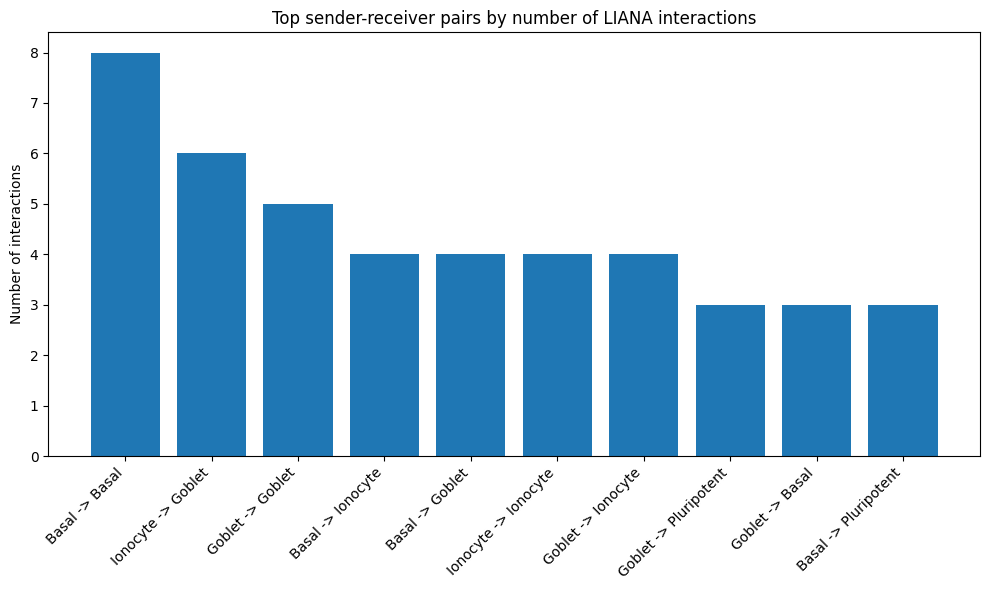

Saved figure to: ../figures/top_sender_receiver_pairs.png


In [18]:
# Step 17: Plot top sender-receiver pairs

top_n = 10
plot_df = pair_counts.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(
    range(len(plot_df)),
    plot_df["n_interactions"]
)

plt.xticks(
    range(len(plot_df)),
    [f"{row.source} -> {row.target}" for _, row in plot_df.iterrows()],
    rotation=45,
    ha="right"
)

plt.ylabel("Number of interactions")
plt.title("Top sender-receiver pairs by number of LIANA interactions")
plt.tight_layout()

plot_path = os.path.join(figures_dir, "top_sender_receiver_pairs.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", plot_path)

In [15]:
# Step 18: Inspect selected biologically relevant cell-type pairs

selected_pairs = liana_res[
    (liana_res["source"] == "Early epithelial progenitor") &
    (liana_res["target"] == "Goblet")
].sort_values("magnitude_rank", ascending=True)

selected_pairs.head(20)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair
26,Early epithelial progenitor,Goblet,MDK,NCL,1.490315,0.836,0.572127,-0.090939,-9.249641,0.021294,0.938555,1.0,0.116248,MDK -> NCL


In [20]:
# Step 19: Save selected pair interactions

selected_pair_path = os.path.join(
    results_dir,
    "liana_EarlyEpithelialProgenitor_to_Goblet.csv"
)

selected_pairs.to_csv(selected_pair_path, index=False)

print("Saved selected pair interactions to:", selected_pair_path)

Saved selected pair interactions to: ../results/liana_EarlyEpithelialProgenitor_to_Goblet.csv


In [16]:
print(liana_res["ligand_complex"].value_counts().head(20))
print(liana_res["receptor_complex"].value_counts().head(20))

ligand_complex
MDK      32
L1CAM    21
CDH1      6
CALM1     5
BMP7      3
ARF6      2
LAMA5     2
HRG       1
LUM       1
LAMC1     1
CGN       1
APOE      1
Name: count, dtype: int64
receptor_complex
NCL       24
CD9       18
PTPRF      6
HMMR       5
SDC2       5
ERBB3      4
TSPAN1     4
ACTR2      3
SMAP1      2
DAG1       2
BCAM       1
ITGB1      1
OCLN       1
Name: count, dtype: int64
